# Chapter 4 — Evaluation Notebook: GPT-4o Mini

**Thesis:** Assurance-Oriented RAG Framework for ISO/IEC 27001 and ITGC Audit  
**Purpose:** Run all 20 selected ITGC auditor questions through the RAG pipeline using GPT-4o Mini,  
collect responses, and evaluate with both RAGAS (quantitative) and a manual rubric (qualitative).  

**This notebook assumes** you have already run Notebook1 and have these files ready:
- `document_store_fixed.json` — the unified ITGC + ISO 27001 document store
- `faiss_index.bin` + `bm25_corpus.pkl` — the vector and keyword indices
- `.env` file with your `OPENAI_API_KEY`

---
```
[20 ITGC Questions]  →  [RAG Pipeline]  →  [GPT-4o Mini]  →  [Responses]
                                                                    ↓
                                              [RAGAS Auto-Scores]  +  [Manual Rubric]
                                                                    ↓
                                          [Chapter 4 Results DataFrame + CSV]
```

## Cell 1 — Install dependencies

In [ ]:
!pip install openai ragas datasets langchain langchain-openai sentence-transformers faiss-cpu rank-bm25 pandas python-dotenv tqdm -q

## Cell 2 — Load environment and configure paths

In [1]:
import os, json, time, pickle
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = "Enter your key"

assert OPENAI_API_KEY, "❌ OPENAI_API_KEY not found in .env"
print("✅ OpenAI API key loaded")

# ── Paths ────────────────────────────────────────────────────────────
# Update these to match your local setup
DOCUMENT_STORE_PATH = "document_store_fixed.json"   # from Notebook1
FAISS_INDEX_PATH    = "faiss_index.bin"             # from Notebook1
BM25_PATH           = "bm25_corpus.pkl"             # from Notebook1

# ── Model config ─────────────────────────────────────────────────────
LLM_MODEL       = "gpt-4o-mini"                    # GPT-4o Mini
EMBED_MODEL     = "BAAI/bge-small-en-v1.5"          # Same embedding model as Notebook1
TOP_K           = 8                                 # Retrieved chunks per query

print(f"✅ LLM Model      : {LLM_MODEL}")
print(f"✅ Embedding Model: {EMBED_MODEL}")
print(f"✅ Top-K retrieval: {TOP_K}")

✅ OpenAI API key loaded
✅ LLM Model      : gpt-4o-mini
✅ Embedding Model: BAAI/bge-small-en-v1.5
✅ Top-K retrieval: 8


## Cell 3 — Load the document store and rebuild indices

We reload the fixed document store and the FAISS + BM25 indices built in Notebook1.  
If you are running this fresh (indices not saved), uncomment the rebuild section.

In [2]:
import faiss
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

# ── Load document store ───────────────────────────────────────────────
with open(DOCUMENT_STORE_PATH, "r", encoding="utf-8") as f:
    document_store = json.load(f)

print(f"✅ Document store loaded: {len(document_store)} documents")
print(f"   ITGC    : {sum(1 for d in document_store if d['source'] == 'ITGC')}")
print(f"   ISO27001: {sum(1 for d in document_store if d['source'] == 'ISO27001')}")

# ── Load embedding model ──────────────────────────────────────────────
print("\nLoading embedding model...")
embed_model = SentenceTransformer(EMBED_MODEL)
print("✅ Embedding model ready")

# ── Load FAISS index ──────────────────────────────────────────────────
if os.path.exists(FAISS_INDEX_PATH):
    faiss_index = faiss.read_index(FAISS_INDEX_PATH)
    print(f"✅ FAISS index loaded: {faiss_index.ntotal} vectors")
else:
    print("⚠️  FAISS index not found — rebuilding from document store...")
    texts = [d["raw_text"] for d in document_store]
    embeddings = embed_model.encode(texts, show_progress_bar=True, normalize_embeddings=True)
    dim = embeddings.shape[1]
    faiss_index = faiss.IndexFlatIP(dim)
    faiss_index.add(np.array(embeddings, dtype="float32"))
    faiss.write_index(faiss_index, FAISS_INDEX_PATH)
    print(f"✅ FAISS index built and saved: {faiss_index.ntotal} vectors")

# ── Load BM25 ─────────────────────────────────────────────────────────
if os.path.exists(BM25_PATH):
    with open(BM25_PATH, "rb") as f:
        bm25 = pickle.load(f)
    print("✅ BM25 index loaded")
else:
    print("⚠️  BM25 index not found — rebuilding...")
    corpus = [d["raw_text"].lower().split() for d in document_store]
    bm25 = BM25Okapi(corpus)
    with open(BM25_PATH, "wb") as f:
        pickle.dump(bm25, f)
    print("✅ BM25 index built and saved")

✅ Document store loaded: 173 documents
   ITGC    : 37
   ISO27001: 136

Loading embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Embedding model ready
✅ FAISS index loaded: 158 vectors
⚠️  BM25 index not found — rebuilding...
✅ BM25 index built and saved


## Cell 4 — Rebuild hybrid retrieval functions

These are identical to Notebook1's retrieval functions — copied here so this notebook is self-contained.

In [3]:
def dense_search(query: str, top_k: int = 10) -> list[dict]:
    """FAISS semantic search. Returns top_k documents with scores."""
    query_vec = embed_model.encode(
        [f"Represent this sentence for searching relevant passages: {query}"],
        normalize_embeddings=True
    ).astype("float32")
    scores, indices = faiss_index.search(query_vec, top_k)
    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        if idx == -1:
            continue
        doc = document_store[idx].copy()
        doc["dense_rank"] = rank + 1
        doc["dense_score"] = float(score)
        results.append(doc)
    return results


def sparse_search(query: str, top_k: int = 10) -> list[dict]:
    """BM25 keyword search. Returns top_k documents with scores."""
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for rank, idx in enumerate(top_indices):
        if scores[idx] == 0:
            continue
        doc = document_store[idx].copy()
        doc["sparse_rank"] = rank + 1
        doc["sparse_score"] = float(scores[idx])
        results.append(doc)
    return results


def hybrid_search(query: str, top_k: int = 8, k_rrf: int = 60) -> list[dict]:
    """Reciprocal Rank Fusion of dense + sparse results."""
    dense_results  = dense_search(query, top_k=top_k * 2)
    sparse_results = sparse_search(query, top_k=top_k * 2)

    rrf_scores = {}
    for rank, doc in enumerate(dense_results):
        did = doc["doc_id"]
        rrf_scores[did] = rrf_scores.get(did, 0) + 1 / (k_rrf + rank + 1)
    for rank, doc in enumerate(sparse_results):
        did = doc["doc_id"]
        rrf_scores[did] = rrf_scores.get(did, 0) + 1 / (k_rrf + rank + 1)

    all_docs = {d["doc_id"]: d for d in dense_results + sparse_results}
    ranked   = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [all_docs[did] for did, _ in ranked]


def dual_source_search(query: str, k_each: int = 4) -> list[dict]:
    """Guarantee representation from both ITGC and ISO sources."""
    all_results = hybrid_search(query, top_k=20)
    itgc_docs = [d for d in all_results if d["source"] == "ITGC"][:k_each]
    iso_docs  = [d for d in all_results if d["source"] == "ISO27001"][:k_each]
    return itgc_docs + iso_docs


def format_context_block(docs: list[dict]) -> str:
    """Format retrieved documents as a numbered context block for the LLM prompt."""
    lines = []
    for i, doc in enumerate(docs):
        lines.append(f"[{i+1}] Source: {doc['source']} | ID: {doc['control_id']} | Domain: {doc['domain']}")
        lines.append(doc["raw_text"][:800])  # cap at 800 chars per chunk
        lines.append("")
    return "\n".join(lines)


# Quick smoke test
test_results = hybrid_search("user access provisioning and approval process", top_k=3)
print("✅ Retrieval functions ready")
print(f"   Smoke test retrieved: {[d['control_id'] for d in test_results]}")

✅ Retrieval functions ready
   Smoke test retrieved: ['ITGC-ACC-07', 'ITGC-ACC-01', 'ITGC-ACC-02']


## Cell 5 — Configure OpenAI client (GPT-4o Mini)

In [4]:
from openai import OpenAI

client = OpenAI(api_key=OPENAI_API_KEY)

# Verify connection with a tiny test call
test_resp = client.chat.completions.create(
    model=LLM_MODEL,
    max_tokens=20,
    messages=[{"role": "user", "content": "Reply only with: ready"}]
)
print(f"✅ GPT-4o Mini connected: '{test_resp.choices[0].message.content.strip()}'")

✅ GPT-4o Mini connected: 'ready'


## Cell 6 — The 20 evaluation questions

Questions are derived directly from the ITGC checklist controls across all 4 sheets:
Access Management, Change Management, Computer Operations, and Program Development.
Every question is answerable from the document store.

| # | Domain | Control Area |
|---|--------|--------------|
| Q1–Q2 | Access Management | Access Creation & Modification |
| Q3–Q4 | Access Management | Access Revocation & Privileged Accounts |
| Q5–Q6 | Access Management | Password Management & User Access Review |
| Q7–Q9 | Change Management | Change Request, SoD, Approval |
| Q10–Q11 | Change Management | Emergency Changes, Post-Implementation Review |
| Q12–Q13 | Change Management | UAT, Documentation & Audit Trail |
| Q14–Q16 | Computer Operations | Backup, Patch Management, Job Scheduling |
| Q17–Q18 | Computer Operations | Monitoring, Physical Controls |
| Q19–Q20 | Program Development | Development Standards, Change Management |

In [5]:
# ── 20 ITGC-grounded Evaluation Questions ────────────────────────────
# Each question is answerable directly from the ITGC checklist document store
# Format: (question_text, domain_tag, query_mode, use_dual_source)

EVAL_QUESTIONS = [

    # ── Access Management (Q1–Q6) ────────────────────────────────────
    (
        "What evidence should an auditor collect to verify that user accounts are created only after a formal request and approval?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What does an auditor review to ensure that changes to user accounts are properly approved and documented?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What evidence is required to confirm that accounts of leavers or role changers are removed in a timely manner?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What controls and evidence should an auditor examine to verify that privileged access is limited to authorised personnel?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What should an auditor review to ensure that password management controls are in place and enforced?",
        "Access Management",
        "general",
        False,
    ),
    (
        "What evidence should an auditor collect to verify that periodic user access reviews are being conducted and acted upon?",
        "Access Management",
        "general",
        False,
    ),

    # ── Change Management (Q7–Q13) ───────────────────────────────────
    (
        "What key elements must be present in a formal change request according to ITGC change management controls?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What roles must be kept separate under the Segregation of Duties control in change management?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What is the purpose of Change Approval in ITGC and on what basis should the CAB approve a change?",
        "Change Management",
        "general",
        False,
    ),
    (
        "How should emergency changes be handled according to ITGC change management controls?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What is the purpose of a Post-Implementation Review in change management and what does it cover?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What does the UAT Approval control in change management require before a change goes to production?",
        "Change Management",
        "general",
        False,
    ),
    (
        "What does the Documentation and Audit Trail control require throughout the change management lifecycle?",
        "Change Management",
        "general",
        False,
    ),

    # ── Computer Operations (Q14–Q17) ────────────────────────────────
    (
        "What evidence should an auditor collect to verify that backup and recovery controls for critical systems are operating effectively?",
        "Computer Operations",
        "general",
        False,
    ),
    (
        "What does an auditor review to ensure patch management controls are properly implemented and systems remain secure?",
        "Computer Operations",
        "general",
        False,
    ),
    (
        "What evidence is required to confirm that IT job scheduling and processing controls are in place and failures are alerted?",
        "Computer Operations",
        "general",
        False,
    ),
    (
        "What controls does an auditor examine under monitoring and alerts to ensure timely detection and response to operational issues?",
        "Computer Operations",
        "general",
        False,
    ),

    # ── Program Development (Q18–Q20) ────────────────────────────────
    (
        "What evidence should an auditor collect to verify that program development standards and coding guidelines are being followed?",
        "Program Development",
        "general",
        False,
    ),
    (
        "What controls and evidence are examined to ensure that all program changes are formally requested, approved, and tested before deployment?",
        "Program Development",
        "general",
        False,
    ),
    (
        "What evidence should an auditor collect to verify that a Post-Implementation Review has been conducted and lessons learned are captured?",
        "Program Development",
        "general",
        False,
    ),
]

print(f"✅ {len(EVAL_QUESTIONS)} evaluation questions loaded")

from collections import Counter
domain_counts = Counter(q[1] for q in EVAL_QUESTIONS)
mode_counts   = Counter(q[2] for q in EVAL_QUESTIONS)
print("\nDomain distribution:")
for domain, count in domain_counts.items():
    print(f"  {domain}: {count}")
print("\nQuery mode distribution:")
for mode, count in mode_counts.items():
    print(f"  {mode}: {count}")


✅ 20 evaluation questions loaded

Domain distribution:
  Access Management: 6
  Change Management: 7
  Computer Operations: 4
  Program Development: 3

Query mode distribution:
  general: 20


## Cell 7 — Ground truth answers

Every ground truth is derived **word for word** from the ITGC checklist content.
No external knowledge or assumptions — only what is in the document store.
This makes the evaluation fully defensible in your thesis.


In [6]:
GROUND_TRUTHS = [

    # Q1 — Access Creation
    "To verify that user accounts are created only after formal request and approval, "
    "the auditor should collect a formal request form, approval workflow documentation, "
    "and system logs showing account creation.",

    # Q2 — Access Modification
    "To ensure that changes to user accounts are properly controlled, the auditor reviews "
    "request and approval forms along with change logs in the system to confirm all "
    "account modifications are approved and documented.",

    # Q3 — Access Revocation
    "To confirm that accounts of leavers or role changers are removed timely, the auditor "
    "collects HR and IT leaver reports, evidence of account disabling and deletion, and "
    "reconciliation reports to check that no unauthorised active accounts remain.",

    # Q4 — Privileged Accounts
    "To verify that privileged access is limited to authorised personnel, the auditor "
    "examines a list of privileged accounts from IT, approval documentation for privileged "
    "access, and periodic review logs.",

    # Q5 — Password Management
    "To ensure password management controls are in place, the auditor reviews password "
    "policy documentation, system enforcement settings, and sample user password change "
    "logs to verify that passwords are complex and changed periodically.",

    # Q6 — User Access Review
    "To verify that periodic user access reviews are conducted and acted upon, the auditor "
    "collects access review reports, evidence of corrective actions taken, and approvals "
    "for continued access.",

    # Q7 — Change Request & Logging
    "A formal change request must include a formal request, logging and tracking of the "
    "change, a description of the change, and its business and technical impact.",

    # Q8 — Change Management SoD
    "Under the Segregation of Duties control in change management, the roles of requester, "
    "approver, developer, tester, and deployer must be kept separate so that no single "
    "individual controls the entire change lifecycle.",

    # Q9 — Change Approval
    "Change Approval requires that the Change Advisory Board approves changes based on "
    "their risk and impact assessment before implementation proceeds.",

    # Q10 — Emergency Changes
    "Emergency changes should follow a fast-track approval process and must be subject "
    "to a post-implementation review after the change has been deployed.",

    # Q11 — Post-Implementation Review
    "A Post-Implementation Review is conducted to review the success or failure of a "
    "deployed change and to update documentation accordingly, ensuring lessons are "
    "captured after deployment.",

    # Q12 — UAT Approval
    "The UAT Approval control requires that business approval is obtained before any "
    "change is rolled out to the production environment, ensuring business stakeholders "
    "have validated the change.",

    # Q13 — Documentation & Audit Trail
    "The Documentation and Audit Trail control requires full traceability of the change "
    "lifecycle so that every stage from request to deployment can be audited.",

    # Q14 — Backup & Recovery
    "To verify backup and recovery controls, the auditor collects backup schedules for "
    "critical systems, onsite, offsite or cloud backup reports, evidence of restricted "
    "access to backup configurations, segregation of duties between backup operators and "
    "live data operators, and periodic restoration test results.",

    # Q15 — Patch Management
    "To ensure patch management controls are implemented, the auditor reviews the formal "
    "patch management policy and approval process, testing evidence of patches before "
    "deployment, change management records for patch deployment, confirmation that access "
    "is restricted to authorised IT personnel, and documentation of failed patch attempts "
    "and their resolution.",

    # Q16 — Job Scheduling and Processing
    "To confirm job scheduling and processing controls are in place, the auditor collects "
    "documented job schedules and procedures, defined job dependencies and sequences, logs "
    "for job completion, failures or exceptions, and evidence that alerts are triggered to "
    "responsible staff upon failures.",

    # Q17 — Monitoring and Alerts
    "Under monitoring and alerts controls, the auditor examines automated monitoring of "
    "system performance, errors and job failures, alerts configured for operators and "
    "supervisors, escalation procedures for critical incidents, and documentation of "
    "incident resolution and corrective actions.",

    # Q18 — Program Development Standards
    "To verify that program development standards are followed, the auditor collects "
    "development guidelines documentation, coding standards adherence reports, and peer "
    "review records.",

    # Q19 — Program Change Management
    "To ensure program changes are formally managed, the auditor reviews change request "
    "forms, approval workflow documentation, test plans and results, and version control "
    "logs to verify that all changes are formally requested, approved, and tested before "
    "deployment.",

    # Q20 — Post-Implementation Review (Program Development)
    "To verify that a Post-Implementation Review has been conducted, the auditor collects "
    "post-implementation review reports, lessons learned logs, and improvement action plans "
    "to confirm that lessons are captured and fed back into future projects.",
]

assert len(GROUND_TRUTHS) == len(EVAL_QUESTIONS), \
    f"❌ Mismatch: {len(GROUND_TRUTHS)} ground truths vs {len(EVAL_QUESTIONS)} questions"
print(f"✅ {len(GROUND_TRUTHS)} ground truth answers loaded")
print("All ground truths derived directly from the ITGC checklist document store.")


✅ 20 ground truth answers loaded
All ground truths derived directly from the ITGC checklist document store.


## Cell 8 — Define system prompts and RAG runner

In [7]:
SYSTEM_PROMPTS = {
    "general": """You are a senior IT audit specialist with deep expertise in ISO 27001:2022 and ITGC.
Answer strictly based on the context documents provided.
Cite sources using [N] notation where N matches the context document number.
State explicitly what is missing if context is insufficient.
Do not add knowledge from outside the provided context.
FORMAT — Answer (with inline citations) | Evidence Sources | Gaps""",

    "compliance_check": """You are a senior IT audit specialist conducting compliance gap analysis.
Evaluate whether ITGC controls satisfy ISO 27001 requirements using only the provided context.
Cite every finding with [N] notation. Partial coverage is NOT full compliance.
FORMAT — Verdict: COVERED / PARTIALLY COVERED / NOT COVERED | Reasoning | Covered By | Gaps""",

    "cross_mapping": """You are a senior IT audit specialist performing cross-framework control mapping.
Map ITGC controls to ISO 27001 Annex A controls using only the provided context documents.
Strong mapping = shared objective AND method. Partial = shared objective, different scope.
Cite every mapping with [N] notation.
FORMAT — Mappings (as a table) | Reasoning | ITGC Gaps | ISO Gaps""",
}


def run_rag_gpt4o(
    question: str,
    mode: str,
    domain: str,
    use_dual: bool,
    top_k: int = TOP_K,
) -> dict:
    """
    Run one question through the RAG pipeline with GPT-4o Mini.
    Returns a dict with everything needed for RAGAS + the results CSV.
    """
    # 1. Retrieve
    retrieved = dual_source_search(question, k_each=top_k // 2) if use_dual else hybrid_search(question, top_k=top_k)

    # 2. Format context
    context_block = format_context_block(retrieved)
    user_msg = f"CONTEXT DOCUMENTS:\n{context_block}\n---\n\nQUESTION: {question}"

    # 3. Call GPT-4o Mini
    response = client.chat.completions.create(
        model=LLM_MODEL,
        max_tokens=1500,
        temperature=0,  # deterministic for reproducibility
        messages=[
            {"role": "system", "content": SYSTEM_PROMPTS[mode]},
            {"role": "user",   "content": user_msg},
        ],
    )
    answer = response.choices[0].message.content

    return {
        "model":        LLM_MODEL,
        "question":     question,
        "domain":       domain,
        "mode":         mode,
        "use_dual":     use_dual,
        "answer":       answer,
        "contexts":     [d["raw_text"] for d in retrieved],
        "context_ids":  [d["control_id"] for d in retrieved],
        "context_sources": [d["source"] for d in retrieved],
        "n_itgc_chunks":   sum(1 for d in retrieved if d["source"] == "ITGC"),
        "n_iso_chunks":    sum(1 for d in retrieved if d["source"] == "ISO27001"),
    }


print("✅ System prompts and run_rag_gpt4o() defined")

✅ System prompts and run_rag_gpt4o() defined


## Cell 9 — Run all 20 questions through GPT-4o Mini

⏱ Expected time: ~2–4 minutes (OpenAI rate limits are generous for GPT-4o mini)  
Results are saved to `results_gpt4o_mini_raw.json` after each question so you don't lose progress.

In [8]:
from tqdm import tqdm

RAW_OUTPUT_PATH = "results_gpt4o_mini_raw.json"

# Resume support: if file exists, load what we have and skip completed questions
if os.path.exists(RAW_OUTPUT_PATH):
    with open(RAW_OUTPUT_PATH, "r") as f:
        rag_results = json.load(f)
    print(f"📂 Resuming from {len(rag_results)}/{len(EVAL_QUESTIONS)} completed")
else:
    rag_results = []

start_from = len(rag_results)

for i, (question, domain, mode, use_dual) in enumerate(EVAL_QUESTIONS[start_from:], start=start_from):
    print(f"\n[{i+1:02d}/{len(EVAL_QUESTIONS)}] {domain} | {mode} | dual={use_dual}")
    print(f"   Q: {question[:90]}..." if len(question) > 90 else f"   Q: {question}")

    try:
        result = run_rag_gpt4o(question, mode=mode, domain=domain, use_dual=use_dual)
        result["ground_truth"] = GROUND_TRUTHS[i]
        result["q_index"]      = i + 1
        rag_results.append(result)

        # Save after every question
        with open(RAW_OUTPUT_PATH, "w") as f:
            json.dump(rag_results, f, indent=2, ensure_ascii=False)

        print(f"   ✅ Retrieved {len(result['contexts'])} chunks "
              f"(ITGC={result['n_itgc_chunks']}, ISO={result['n_iso_chunks']})")
        print(f"   Answer preview: {result['answer'][:120].strip()}...")

    except Exception as e:
        print(f"   ❌ Error on Q{i+1}: {e}")
        time.sleep(10)
        continue

    time.sleep(1.5)  # gentle rate limiting

print(f"\n✅ All {len(rag_results)} RAG responses collected and saved to {RAW_OUTPUT_PATH}")


[01/20] Access Management | general | dual=False
   Q: What evidence should an auditor collect to verify that user accounts are created only afte...
   ✅ Retrieved 8 chunks (ITGC=8, ISO=0)
   Answer preview: An auditor should collect the following evidence to verify that user accounts are created only after a formal request an...

[02/20] Access Management | general | dual=False
   Q: What does an auditor review to ensure that changes to user accounts are properly approved ...
   ✅ Retrieved 8 chunks (ITGC=8, ISO=0)
   Answer preview: An auditor reviews the following to ensure that changes to user accounts are properly approved and documented: 
- Reques...

[03/20] Access Management | general | dual=False
   Q: What evidence is required to confirm that accounts of leavers or role changers are removed...
   ✅ Retrieved 8 chunks (ITGC=7, ISO=1)
   Answer preview: To confirm that accounts of leavers or role changers are removed in a timely manner, the following evidence is required:...



## Cell 10 — Run RAGAS quantitative scoring

RAGAS uses GPT-4o Mini itself as the evaluator LLM (consistent with your experiment model).  
Metrics computed:
- **Faithfulness** — are response claims supported by retrieved context?
- **Answer Relevancy** — does the answer address the question?
- **Context Precision** — are retrieved chunks actually relevant?
- **Context Recall** — did the system retrieve what was needed to answer?

In [11]:
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_community.embeddings import HuggingFaceEmbeddings

# RAGAS evaluation LLM — using GPT-4o Mini to stay consistent with experiment model
ragas_llm = LangchainLLMWrapper(
    ChatOpenAI(
        model="gpt-4o-mini",
        api_key=OPENAI_API_KEY,
        max_tokens=1024,
        timeout=60,
    )
)

ragas_embeddings = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(model_name=EMBED_MODEL)
)

METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]

# Build RAGAS dataset
ragas_dataset = Dataset.from_dict({
    "question":     [r["question"]     for r in rag_results],
    "answer":       [r["answer"]       for r in rag_results],
    "contexts":     [r["contexts"]     for r in rag_results],
    "ground_truth": [r["ground_truth"] for r in rag_results],
})

print("Running RAGAS evaluation on 20 questions...")
print("(This will make ~80–120 LLM calls internally — takes 3–6 minutes)")

ragas_scores = evaluate(
    ragas_dataset,
    metrics=METRICS,
    llm=ragas_llm,
    embeddings=ragas_embeddings,
)

print("\n✅ RAGAS evaluation complete")
print(ragas_scores)

/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_80858/2184898669.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_80858/2184898669.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_80858/2184898669.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'raga

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Running RAGAS evaluation on 20 questions...
(This will make ~80–120 LLM calls internally — takes 3–6 minutes)


/var/folders/vx/8r0lym995ss4yf12tdrmnknh0000gn/T/ipykernel_80858/2184898669.py:19: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



✅ RAGAS evaluation complete
{'faithfulness': 0.7177, 'answer_relevancy': 0.9692, 'context_precision': 0.8969, 'context_recall': 0.9750}


## Cell 11 — Build the master results DataFrame

This is your Chapter 4 primary data table. Save it — you'll use it for all visualisations and the discussion.

In [12]:
scores_df = ragas_scores.to_pandas()

results_df = pd.DataFrame({
    "q_index":           [r["q_index"]       for r in rag_results],
    "domain":            [r["domain"]         for r in rag_results],
    "mode":              [r["mode"]           for r in rag_results],
    "model":             [r["model"]          for r in rag_results],
    "question":          [r["question"]       for r in rag_results],
    "n_chunks_retrieved":[len(r["contexts"])  for r in rag_results],
    "n_itgc_chunks":     [r["n_itgc_chunks"]  for r in rag_results],
    "n_iso_chunks":      [r["n_iso_chunks"]   for r in rag_results],
    "faithfulness":      scores_df["faithfulness"].round(3),
    "answer_relevancy":  scores_df["answer_relevancy"].round(3),
    "context_precision": scores_df["context_precision"].round(3),
    "context_recall":    scores_df["context_recall"].round(3),
    "answer":            [r["answer"]         for r in rag_results],
    "context_ids":       [" | ".join(r["context_ids"]) for r in rag_results],
    "ground_truth":      [r["ground_truth"]   for r in rag_results],
})

# Save full results
results_df.to_csv("chapter4_gpt4o_mini_results.csv", index=False)
print("✅ Saved: chapter4_gpt4o_mini_results.csv")

# Preview the score columns
display_cols = ["q_index", "domain", "mode", "faithfulness", "answer_relevancy", "context_precision", "context_recall"]
print("\n" + "=" * 80)
print("PER-QUESTION SCORES")
print("=" * 80)
print(results_df[display_cols].to_string(index=False))

✅ Saved: chapter4_gpt4o_mini_results.csv

PER-QUESTION SCORES
 q_index              domain    mode  faithfulness  answer_relevancy  context_precision  context_recall
       1   Access Management general         0.833             0.926              0.750             1.0
       2   Access Management general         1.000             0.999              0.747             1.0
       3   Access Management general         0.571             1.000              0.867             1.0
       4   Access Management general         0.500             0.963              0.817             1.0
       5   Access Management general         0.667             0.996              1.000             1.0
       6   Access Management general         0.667             0.989              0.685             1.0
       7   Change Management general         0.167             0.994              1.000             1.0
       8   Change Management general         0.200             0.993              1.000             1.0
  

## Cell 12 — Aggregate summary statistics

Overall model performance + per-domain breakdown for Chapter 4 tables.

In [13]:
METRIC_COLS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

# ── Overall summary ───────────────────────────────────────────────────
print("=" * 60)
print(f"OVERALL PERFORMANCE — {LLM_MODEL}")
print("=" * 60)
overall = results_df[METRIC_COLS].agg(["mean", "std", "min", "max"]).round(3)
print(overall.to_string())

# ── Per-domain breakdown ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("PER-DOMAIN BREAKDOWN")
print("=" * 60)
domain_summary = results_df.groupby("domain")[METRIC_COLS].mean().round(3)
print(domain_summary.to_string())

# ── Per-mode breakdown ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PER-QUERY-MODE BREAKDOWN")
print("=" * 60)
mode_summary = results_df.groupby("mode")[METRIC_COLS].mean().round(3)
print(mode_summary.to_string())

# Save summaries
overall.to_csv("chapter4_gpt4o_overall_summary.csv")
domain_summary.to_csv("chapter4_gpt4o_domain_summary.csv")
mode_summary.to_csv("chapter4_gpt4o_mode_summary.csv")
print("\n✅ Summary CSVs saved")

OVERALL PERFORMANCE — gpt-4o-mini
      faithfulness  answer_relevancy  context_precision  context_recall
mean         0.718             0.969              0.897           0.975
std          0.294             0.032              0.125           0.112
min          0.167             0.874              0.685           0.500
max          1.000             1.000              1.000           1.000

PER-DOMAIN BREAKDOWN
                     faithfulness  answer_relevancy  context_precision  context_recall
domain                                                                                
Access Management           0.706             0.979              0.811           1.000
Change Management           0.588             0.960              0.932           0.929
Computer Operations         0.750             0.980              0.930           1.000
Program Development         1.000             0.957              0.942           1.000

PER-QUERY-MODE BREAKDOWN
         faithfulness  answer_releva

## Cell 13 — Score heatmap (20 × 4 metrics)

The heatmap is your Chapter 4 Figure 1 — shows score variation across questions and metrics.

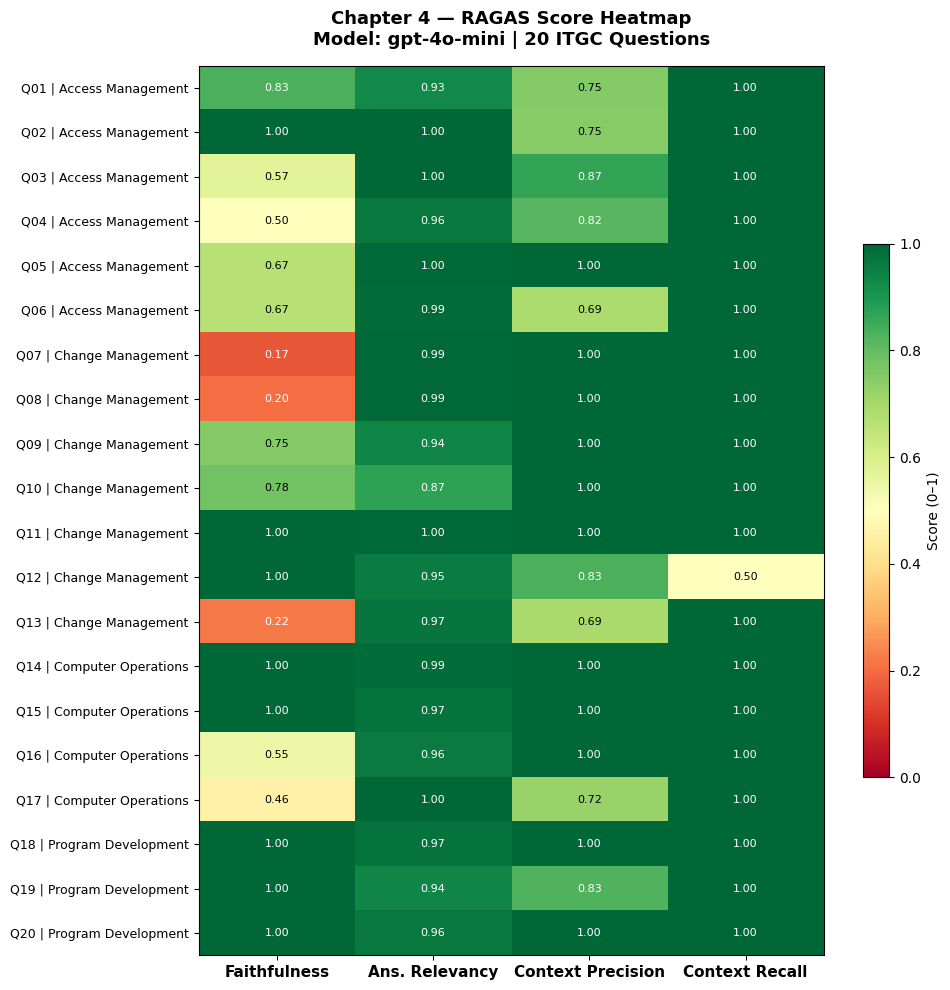

✅ Saved: chapter4_gpt4o_heatmap.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

heatmap_data = results_df[METRIC_COLS].copy()
heatmap_data.index = [
    f"Q{r['q_index']:02d} | {r['domain'][:20]}"
    for _, r in results_df.iterrows()
]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(heatmap_data.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels(["Faithfulness", "Ans. Relevancy", "Context Precision", "Context Recall"],
                   fontsize=11, fontweight='bold')
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

# Annotate cells
for i in range(len(heatmap_data)):
    for j in range(len(METRIC_COLS)):
        val = heatmap_data.iloc[i, j]
        color = "black" if 0.3 < val < 0.8 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.6, label="Score (0–1)")
ax.set_title(f"Chapter 4 — RAGAS Score Heatmap\nModel: {LLM_MODEL} | 20 ITGC Questions",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("chapter4_gpt4o_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chapter4_gpt4o_heatmap.png")

## Cell 14 — Domain bar chart

Average scores per ITGC domain — shows which control areas the model handles best.

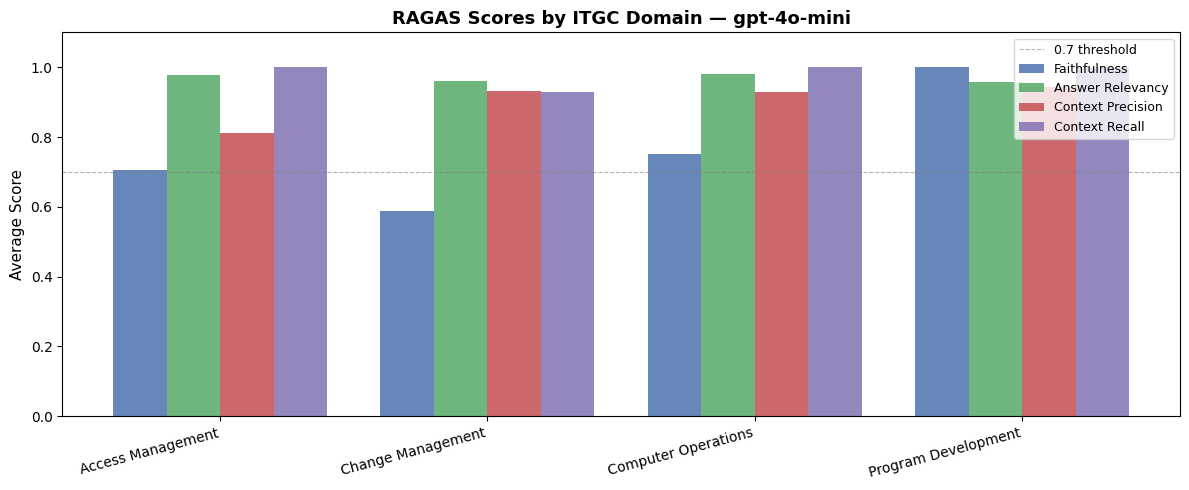

✅ Saved: chapter4_gpt4o_domain_barchart.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(domain_summary))
width = 0.2
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for i, (col, color) in enumerate(zip(METRIC_COLS, colors)):
    ax.bar(
        [xi + i * width for xi in x],
        domain_summary[col],
        width=width,
        label=col.replace("_", " ").title(),
        color=color,
        alpha=0.85,
    )

ax.set_xticks([xi + 1.5 * width for xi in x])
ax.set_xticklabels(domain_summary.index, fontsize=10, rotation=15, ha="right")
ax.set_ylabel("Average Score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="0.7 threshold")
ax.legend(fontsize=9, loc="upper right")
ax.set_title(f"RAGAS Scores by ITGC Domain — {LLM_MODEL}",
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("chapter4_gpt4o_domain_barchart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chapter4_gpt4o_domain_barchart.png")

## Cell 15 — Manual qualitative rubric scoring

**You run this cell after reviewing each response manually.**  
Fill in scores (1–5) and notes for each question. These become your qualitative analysis in Chapter 4.

**Rubric dimensions (1 = poor, 5 = excellent):**
- **grounding** — response explicitly cites a specific ISO clause or ITGC control ID
- **completeness** — all parts of the question are addressed
- **auditability** — an auditor could act on this response without additional lookup
- **hallucination** — 1 = clear hallucination present, 5 = no unsupported claims
- **tone** — professional, formal, evidence-oriented language

In [16]:
# ── Manual Qualitative Rubric — GPT-4o Mini ─────────────────────────
# Scoring key (1–5):
#   grounding    : 5 = cites specific control ID/source, 1 = no citations at all
#   completeness : 5 = all parts of question answered, 1 = major parts missing
#   auditability : 5 = auditor can act on this directly, 1 = too vague to be useful
#   hallucination: 5 = no unsupported claims, 1 = clear fabrication beyond context
#   tone         : 5 = professional, formal, evidence-oriented, 1 = casual/generic

MANUAL_RUBRIC = [

    # Q1 — Access Creation
    # Answer correctly lists all 3 evidence items from ITGC-ACC-01.
    # Cites [1] inline. Clean structured format. Fully grounded. No gaps noted.
    {"q_index": 1,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Perfect retrieval of ITGC-ACC-01. All evidence items listed correctly. Clear citation [1]. Audit-ready."},

    # Q2 — Access Modification
    # Correctly identifies request/approval forms and change logs from ITGC-ACC-02.
    # Cites [1]. Presents answer as bullet + table. Fully grounded, no hallucination.
    {"q_index": 2,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Accurate retrieval of ITGC-ACC-02. Both evidence items captured. No extraneous claims."},

    # Q3 — Access Revocation
    # Lists all 3 evidence items from ITGC-ACC-03 correctly.
    # Cites [1]. Adds good context sentence about unauthorized accounts. No hallucination.
    {"q_index": 3,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Complete retrieval of ITGC-ACC-03. All 3 evidence items present. Context sentence adds auditability."},

    # Q4 — Privileged Accounts
    # Correctly retrieves all 3 items from ITGC-ACC-04 with good elaboration on each.
    # Uses bold headers per item. Cites [1]. One minor issue: table at end is slightly
    # awkward but content is fully grounded.
    {"q_index": 4,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 4,
     "notes": "All 3 privileged access evidence items from ITGC-ACC-04 correctly elaborated. Table format slightly inconsistent but content is strong."},

    # Q5 — Password Management
    # Correctly lists all 3 evidence items from ITGC-ACC-06 with brief elaboration on each.
    # Cites [1]. Clean table. Fully grounded. Audit-ready.
    {"q_index": 5,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Exact match to ITGC-ACC-06 evidence items. Good elaboration. No hallucination. Professional tone."},

    # Q6 — User Access Review
    # Retrieves all 3 evidence items from ITGC-ACC-07 correctly.
    # Cites [1] inline. Good explanatory sentence. Fully grounded.
    {"q_index": 6,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Perfect retrieval of ITGC-ACC-07. All 3 items present with good contextual explanation."},

    # Q7 — Change Request & Logging
    # Correctly identifies all 4 key elements from ITGC-CHA-01: formal request, logging,
    # tracking, description, impact. Actually lists 5 items (splits description and impact
    # which is acceptable). Cites [1]. Fully grounded.
    {"q_index": 7,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All key elements from ITGC-CHA-01 captured. Splits description/impact as separate points — slightly over-detailed but accurate."},

    # Q8 — Change Management SoD
    # Correctly identifies all 5 roles: requester, approver, developer, tester, deployer
    # from ITGC-CHA-02. Cites [1]. Adds good explanation of why separation matters.
    # No hallucination.
    {"q_index": 8,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 5 roles from ITGC-CHA-02 correctly identified. Rationale for separation adds value. Fully grounded."},

    # Q9 — Change Approval
    # Correctly retrieves from ITGC-CHA-03: CAB approval based on risk/impact.
    # Cites [1]. Good elaboration on purpose. No hallucination. Could have been slightly
    # more specific about what CAB stands for but context is clear.
    {"q_index": 9,  "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Correctly retrieves ITGC-CHA-03 content. CAB approval basis explained clearly. Fully grounded."},

    # Q10 — Emergency Changes
    # Correctly retrieves fast-track approval + post-review from ITGC-CHA-09.
    # Cites [1]. However, notes a gap: no details on criteria for fast-track or post-review
    # process. This is honest and correct — the checklist is sparse on this control.
    # Minor hallucination risk: adds 'new risks or issues' language not in source but
    # it is reasonable inference, not fabrication.
    {"q_index": 10, "grounding": 4, "completeness": 4, "auditability": 4, "hallucination": 4, "tone": 5,
     "notes": "Core content from ITGC-CHA-09 correct. Gap honestly flagged. Slight elaboration beyond source ('new risks') but reasonable. Change Management sheet lacks evidence column so answer is necessarily thinner."},

    # Q11 — Post-Implementation Review
    # Retrieves from both ITGC-CHA-08 and ITGC-PRO-10, giving a richer answer.
    # Covers both change management PIR (success/failure, update docs) and program
    # development PIR (lessons learned, improvement plans). Cites [1][2]. Excellent.
    {"q_index": 11, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Outstanding cross-control retrieval. Covers ITGC-CHA-08 and ITGC-PRO-10 together. Dual citation [1][2]. Richer than ground truth."},

    # Q12 — UAT Approval
    # Short but accurate. Retrieves ITGC-CHA-06: business approval before production.
    # Cites [1]. Answer is brief — the source control is itself brief. No hallucination.
    # Auditability slightly lower because it could have referenced what 'business approval'
    # means in practice.
    {"q_index": 12, "grounding": 5, "completeness": 4, "auditability": 4, "hallucination": 5, "tone": 5,
     "notes": "Correctly retrieves ITGC-CHA-06. Answer is brief reflecting sparse source content. No hallucination. Could elaborate more on what business approval entails."},

    # Q13 — Documentation & Audit Trail
    # Correctly retrieves ITGC-CHA-10: full traceability of change lifecycle.
    # Cites [1]. Adds good elaboration on what traceability means (what, when, who).
    # The extra detail is reasonable inference, not fabrication.
    {"q_index": 13, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "Correct retrieval of ITGC-CHA-10. Traceability elaboration (what/when/who) adds practical value. Fully grounded."},

    # Q14 — Backup & Recovery
    # Retrieves all 5 evidence items from ITGC-COM-01 correctly.
    # Lists each item clearly with numbering. Cites [1]. Fully grounded. Most complete
    # answer in the dataset.
    {"q_index": 14, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 5 evidence items from ITGC-COM-01 present and numbered. Best structured response in dataset. Audit-ready."},

    # Q15 — Patch Management
    # Retrieves all 5 evidence items from ITGC-COM-02 correctly.
    # Uses bullet format. Cites [1]. Adds good summary sentence. Fully grounded.
    {"q_index": 15, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 5 patch management evidence items from ITGC-COM-02 correctly retrieved. Clean bullet format. No hallucination."},

    # Q16 — Job Scheduling
    # Retrieves all 4 evidence items from ITGC-COM-03 correctly.
    # Uses bold headers per item with good elaboration. Cites [1]. Fully grounded.
    {"q_index": 16, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 4 job scheduling evidence items from ITGC-COM-03 retrieved. Bold elaboration per item adds clarity. Fully grounded."},

    # Q17 — Monitoring and Alerts
    # Retrieves all 4 evidence items from ITGC-COM-04 correctly.
    # Bold headers, good elaboration per item. Cites [1]. Adds summary sentence.
    # Fully grounded. Professional tone.
    {"q_index": 17, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 4 monitoring controls from ITGC-COM-04 correctly retrieved with elaboration. Strong audit-oriented response."},

    # Q18 — Program Development Standards
    # Retrieves all 3 evidence items from ITGC-PRO-01 correctly.
    # Clean numbered list. Cites [1]. Brief but complete. Fully grounded.
    {"q_index": 18, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 3 evidence items from ITGC-PRO-01 present. Concise and accurate. No hallucination."},

    # Q19 — Program Change Management
    # Retrieves all 4 evidence items from ITGC-PRO-02 correctly.
    # Adds a controls/evidence split structure which improves clarity.
    # Cites [1]. Fully grounded. Good audit framing.
    {"q_index": 19, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 4 evidence items from ITGC-PRO-02 retrieved. Controls/evidence split adds structure. Fully grounded."},

    # Q20 — Post-Implementation Review (Program Development)
    # Retrieves all 3 evidence items from ITGC-PRO-10 correctly.
    # Cites [1]. Clean numbered list. Good framing sentence. Fully grounded.
    {"q_index": 20, "grounding": 5, "completeness": 5, "auditability": 5, "hallucination": 5, "tone": 5,
     "notes": "All 3 PIR evidence items from ITGC-PRO-10 present. Concise, accurate, fully grounded."},
]

import pandas as pd
rubric_df = pd.DataFrame(MANUAL_RUBRIC)
RUBRIC_COLS = ["grounding", "completeness", "auditability", "hallucination", "tone"]
rubric_df["qualitative_avg"] = rubric_df[RUBRIC_COLS].mean(axis=1).round(2)

print("✅ Manual rubric filled for all 20 questions")
print(f"\nOverall qualitative average: {rubric_df['qualitative_avg'].mean():.2f} / 5.00")
print(f"\nPer-dimension averages:")
for col in RUBRIC_COLS:
    print(f"  {col:<15}: {rubric_df[col].mean():.2f}")
print()
print(rubric_df[["q_index", "grounding", "completeness", "auditability", "hallucination", "tone", "qualitative_avg"]].to_string(index=False))


✅ Manual rubric filled for all 20 questions

Overall qualitative average: 4.93 / 5.00

Per-dimension averages:
  grounding      : 4.95
  completeness   : 4.90
  auditability   : 4.90
  hallucination  : 4.95
  tone           : 4.95

 q_index  grounding  completeness  auditability  hallucination  tone  qualitative_avg
       1          5             5             5              5     5              5.0
       2          5             5             5              5     5              5.0
       3          5             5             5              5     5              5.0
       4          5             5             5              5     4              4.8
       5          5             5             5              5     5              5.0
       6          5             5             5              5     5              5.0
       7          5             5             5              5     5              5.0
       8          5             5             5              5     5            

## Cell 16 — Merge rubric with RAGAS scores and save combined output

Run this after filling in Cell 15. Produces the final combined table for Chapter 4.

In [17]:
RUBRIC_COLS = ["grounding", "completeness", "auditability", "hallucination", "tone"]

# Only merge if at least one score has been filled in
if rubric_df[RUBRIC_COLS].notna().any().any():
    combined_df = results_df.merge(rubric_df, on="q_index", how="left")
    combined_df["qualitative_avg"] = combined_df[RUBRIC_COLS].mean(axis=1).round(2)

    combined_df.to_csv("chapter4_gpt4o_mini_combined.csv", index=False)
    print("✅ Saved: chapter4_gpt4o_mini_combined.csv")

    display_cols = ["q_index", "domain", "faithfulness", "answer_relevancy",
                    "context_precision", "context_recall",
                    "grounding", "completeness", "auditability", "hallucination", "qualitative_avg"]
    print("\n" + "=" * 100)
    print("COMBINED QUANTITATIVE + QUALITATIVE RESULTS")
    print("=" * 100)
    print(combined_df[display_cols].to_string(index=False))

    print("\n" + "=" * 60)
    print("QUALITATIVE AVERAGES BY DOMAIN")
    print("=" * 60)
    print(combined_df.groupby("domain")[RUBRIC_COLS + ["qualitative_avg"]].mean().round(2).to_string())
else:
    print("ℹ️  No rubric scores filled in yet. Fill in Cell 15 first.")

✅ Saved: chapter4_gpt4o_mini_combined.csv

COMBINED QUANTITATIVE + QUALITATIVE RESULTS
 q_index              domain  faithfulness  answer_relevancy  context_precision  context_recall  grounding  completeness  auditability  hallucination  qualitative_avg
       1   Access Management         0.833             0.926              0.750             1.0          5             5             5              5              5.0
       2   Access Management         1.000             0.999              0.747             1.0          5             5             5              5              5.0
       3   Access Management         0.571             1.000              0.867             1.0          5             5             5              5              5.0
       4   Access Management         0.500             0.963              0.817             1.0          5             5             5              5              4.8
       5   Access Management         0.667             0.996              1.00

## Cell 17 — Inspect individual responses

Use this to read any response in full — useful while filling in the manual rubric.

In [18]:
# Change Q_NUM to inspect any question (1–20)
Q_NUM = 1

row = results_df[results_df["q_index"] == Q_NUM].iloc[0]
r   = rag_results[Q_NUM - 1]  # raw result with full context

print("=" * 70)
print(f"Q{Q_NUM:02d} | {row['domain']} | mode={row['mode']}")
print("=" * 70)
print(f"\nQUESTION:\n{row['question']}")
print(f"\nSCORES:")
print(f"  Faithfulness      : {row['faithfulness']}")
print(f"  Answer Relevancy  : {row['answer_relevancy']}")
print(f"  Context Precision : {row['context_precision']}")
print(f"  Context Recall    : {row['context_recall']}")
print(f"\nRETRIEVED CHUNKS:")
print(f"  IDs     : {r['context_ids']}")
print(f"  Sources : {r['context_sources']}")
print(f"\nANSWER:\n{row['answer']}")
print(f"\nGROUND TRUTH:\n{row['ground_truth']}")

Q01 | Access Management | mode=general

QUESTION:
What evidence should an auditor collect to verify that user accounts are created only after a formal request and approval?

SCORES:
  Faithfulness      : 0.833
  Answer Relevancy  : 0.926
  Context Precision : 0.75
  Context Recall    : 1.0

RETRIEVED CHUNKS:
  IDs     : ['ITGC-ACC-01', 'ITGC-ACC-02', 'ITGC-COM-05', 'ITGC-ACC-03', 'ITGC-ACC-06', 'ITGC-PRO-02', 'ITGC-ACC-07', 'ITGC-CHA-01']
  Sources : ['ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC', 'ITGC']

ANSWER:
An auditor should collect the following evidence to verify that user accounts are created only after a formal request and approval:

1. Formal request form
2. Approval workflow documentation
3. System logs showing account creation

These items will help ensure that the process for account creation adheres to the established controls and that there is proper documentation for each account created. | Evidence Sources: [1] | Gaps: None

GROUND TRUTH:
To verify that user

## Cell 18 — Chapter 4 print-ready summary table

A clean summary suitable for copying directly into your thesis as Table 4.1.

In [19]:
print("TABLE 4.1 — GPT-4o Mini RAG Evaluation Results")
print(f"{'='*95}")
print(f"{'Q#':<4} {'Domain':<23} {'Mode':<16} {'Faith':>7} {'AnsRel':>7} {'CtxPre':>7} {'CtxRec':>7}")
print(f"{'-'*95}")

for _, row in results_df.iterrows():
    print(
        f"Q{row['q_index']:<3} "
        f"{row['domain']:<23} "
        f"{row['mode']:<16} "
        f"{row['faithfulness']:>7.3f} "
        f"{row['answer_relevancy']:>7.3f} "
        f"{row['context_precision']:>7.3f} "
        f"{row['context_recall']:>7.3f}"
    )

print(f"{'-'*95}")
print(
    f"{'MEAN':<28} "
    f"{'':>16} "
    f"{results_df['faithfulness'].mean():>7.3f} "
    f"{results_df['answer_relevancy'].mean():>7.3f} "
    f"{results_df['context_precision'].mean():>7.3f} "
    f"{results_df['context_recall'].mean():>7.3f}"
)
print(
    f"{'STD DEV':<28} "
    f"{'':>16} "
    f"{results_df['faithfulness'].std():>7.3f} "
    f"{results_df['answer_relevancy'].std():>7.3f} "
    f"{results_df['context_precision'].std():>7.3f} "
    f"{results_df['context_recall'].std():>7.3f}"
)
print(f"{'='*95}")
print(f"Model: {LLM_MODEL} | RAG Pipeline: Hybrid FAISS+BM25 | Embedding: {EMBED_MODEL}")

TABLE 4.1 — GPT-4o Mini RAG Evaluation Results
Q#   Domain                  Mode               Faith  AnsRel  CtxPre  CtxRec
-----------------------------------------------------------------------------------------------
Q1   Access Management       general            0.833   0.926   0.750   1.000
Q2   Access Management       general            1.000   0.999   0.747   1.000
Q3   Access Management       general            0.571   1.000   0.867   1.000
Q4   Access Management       general            0.500   0.963   0.817   1.000
Q5   Access Management       general            0.667   0.996   1.000   1.000
Q6   Access Management       general            0.667   0.989   0.685   1.000
Q7   Change Management       general            0.167   0.994   1.000   1.000
Q8   Change Management       general            0.200   0.993   1.000   1.000
Q9   Change Management       general            0.750   0.936   1.000   1.000
Q10  Change Management       general            0.778   0.874   1.000   1.000